# Biotar Lens Simulation
Python implementation matching the HLSL lens simulation.

In [11]:
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Add this folder to path for local module imports
sys.path.insert(0, r"C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig")

# Force reload the module to pick up changes
if 'lens_simulation' in sys.modules:
    importlib.reload(sys.modules['lens_simulation'])

from lens_simulation import (
    setApertureTexturePath, createLensElements, traceRayForward, addLensProfile
)

# Configuration
APERTURE_SHAPE_PATH = r"C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\Assets\NoiseTextures\UniformStar\UniformStar.png"
setApertureTexturePath(APERTURE_SHAPE_PATH)

APERTURE_STOP_INDEX = 6
D_TO_FILM = 50.0
LENS_ELEMENTS = createLensElements(APERTURE_STOP_INDEX, D_TO_FILM)
LENS_LENGTH_MM = sum(e.thickness for e in LENS_ELEMENTS[:-1])

### Lens Profile

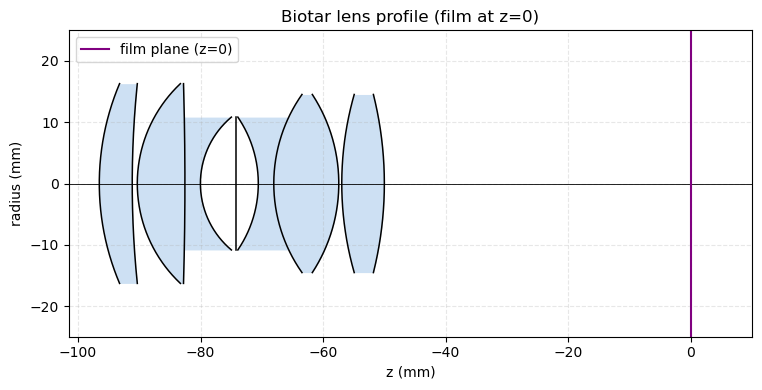

In [12]:
fig, ax = plt.subplots(figsize=(12.0, 4.0))
addLensProfile(ax, LENS_ELEMENTS)
ax.axhline(0, color="black", linewidth=0.6)
ax.axvline(0, color="purple", linewidth=1.5, label="film plane (z=0)")
ax.set(xlim=(-LENS_LENGTH_MM - D_TO_FILM - 5, 10), ylim=(-25, 25), 
       xlabel="z (mm)", ylabel="radius (mm)", title="Biotar lens profile (film at z=0)")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

## Focus from Two Rays
Find focus point by tracing two rays from an object point through the lens.

In [13]:
def focus_from_two_rays(object_distance_mm, lensElements, entry_scale=0.8, recordPath=False):
    """
    Find focus point by tracing two rays from an object point.
    
    Parameters:
        object_distance_mm: Distance from lens entry to object (positive = in front of lens)
        lensElements: List of LensElement objects
        entry_scale: Fraction of aperture radius for the edge ray
        recordPath: If True, return ray paths for visualization
    
    Returns:
        dict with 'point' (focus xyz), 'residual_mm' (ray separation), and optionally 'paths'
    """
    entry = entry_scale * lensElements[0].apertureRadius
    origin = np.array([0.0, 0.0, -object_distance_mm], dtype=float)
    aims = (np.array([0.01, 0.0, 0.0]), np.array([entry, 0.0, 0.0]))
    rays = [traceRayForward(origin, aim, lensElements, recordPath, ignoreAperture=True) for aim in aims]
    if any(r is None for r in rays):
        return None
    p1, d1 = rays[0]["position"], rays[0]["direction"]
    p2, d2 = rays[1]["position"], rays[1]["direction"]
    
    # Find closest approach of two rays in 3D
    a, b, c, w0 = np.dot(d1, d1), np.dot(d1, d2), np.dot(d2, d2), p1 - p2
    d, e, denom = np.dot(d1, w0), np.dot(d2, w0), a*c - b*b
    if abs(denom) < 1e-12:
        return None
    t1, t2 = (b*e - c*d) / denom, (a*e - b*d) / denom
    q1, q2 = p1 + t1*d1, p2 + t2*d2
    
    result = {"point": 0.5*(q1 + q2), "residual_mm": np.linalg.norm(q1 - q2)}
    if recordPath:
        result["paths"] = [r["path"] for r in rays]
    return result

### Ray Convergence Test

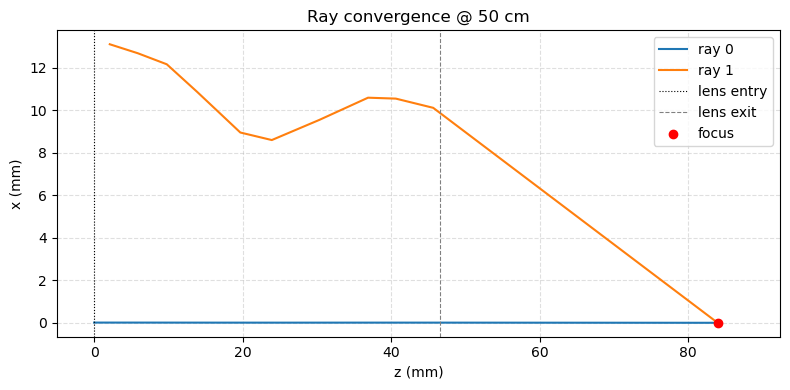

Focus beyond lens: 37.457mm, Residual: 0.000µm


In [14]:
object_distance_cm = 50.0
focus_info = focus_from_two_rays(object_distance_cm * 10.0, LENS_ELEMENTS, recordPath=True)

if focus_info:
    focus = focus_info["point"]
    fig, ax = plt.subplots(figsize=(8.0, 4.0))
    for idx, path in enumerate(focus_info.get("paths", [])):
        segment = path[path[:, 2] >= -5.0]
        ax.plot(np.vstack([segment, focus])[:, 2], np.vstack([segment, focus])[:, 0], label=f"ray {idx}")
    ax.axvline(0.0, color="black", linewidth=0.8, linestyle=":", label="lens entry")
    ax.axvline(LENS_LENGTH_MM, color="gray", linewidth=0.8, linestyle="--", label="lens exit")
    ax.scatter([focus[2]], [focus[0]], color="red", zorder=5, label="focus")
    ax.set(xlabel="z (mm)", ylabel="x (mm)", title=f"Ray convergence @ {object_distance_cm:.0f} cm", xlim=(-5, focus[2]*1.1))
    ax.grid(True, linestyle="--", alpha=0.4); ax.legend(); plt.tight_layout(); plt.show()
    print(f"Focus beyond lens: {focus[2]-LENS_LENGTH_MM:.3f}mm, Residual: {focus_info['residual_mm']*1e3:.3f}µm")

## Focus Distance Fitting
Fit `d_to_film` as a function of object distance for HLSL integration.

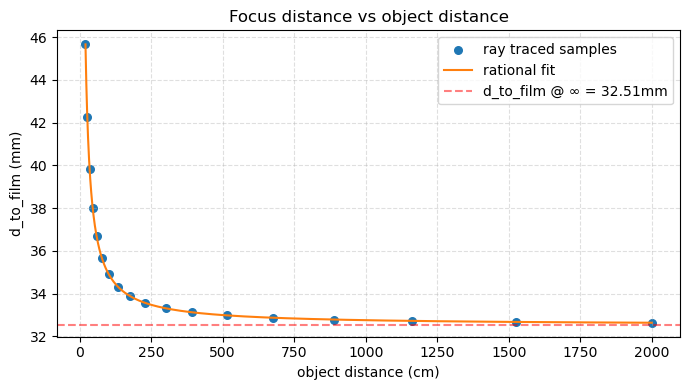

Fit: d_to_film(x) = 237.480/(x + -1.939) + 32.514

At object distance → ∞: d_to_film → 32.514 mm (back focal distance)

Object Distance -> d_to_film
     30 cm  ->  40.977 mm
     50 cm  ->  37.455 mm
    100 cm  ->  34.936 mm
    200 cm  ->  33.713 mm
    500 cm  ->  32.991 mm
   1000 cm  ->  32.752 mm


In [15]:
# Collect samples: (object_distance_cm, d_to_film_mm)
_samples = [(d, focus_from_two_rays(d*10, LENS_ELEMENTS)["point"][2] - LENS_LENGTH_MM) 
            for d in np.geomspace(20, 2000, 18) 
            if (f := focus_from_two_rays(d*10, LENS_ELEMENTS)) and f["residual_mm"] < 1e-3]
obj_cm, d_to_film_mm = np.array(_samples).T

# Fit rational function: d_to_film(x) = a/(x+b) + c
rational_fit = lambda x, a, b, c: a / (x + b) + c
popt, _ = curve_fit(rational_fit, obj_cm, d_to_film_mm, p0=(5000, 0, 40), maxfev=20000)

# Utility function for HLSL integration
def objectDistanceCmToFilmOffset(obj_cm):
    """Convert object distance (cm) to d_to_film (mm) - distance from last lens element to film."""
    return rational_fit(obj_cm, *popt)

FOCAL_LENGTH_AT_INF = popt[2]

# Visualize fit
fig, ax = plt.subplots(figsize=(7.0, 4.0))
ax.scatter(obj_cm, d_to_film_mm, s=30, label="ray traced samples")
ax.plot(np.geomspace(obj_cm.min(), obj_cm.max(), 200), 
        rational_fit(np.geomspace(obj_cm.min(), obj_cm.max(), 200), *popt), 
        color="tab:orange", label="rational fit")
ax.axhline(popt[2], color="red", linestyle="--", alpha=0.5, label=f"d_to_film @ ∞ = {popt[2]:.2f}mm")
ax.set(xlabel="object distance (cm)", ylabel="d_to_film (mm)", 
       title="Focus distance vs object distance")
ax.grid(True, linestyle="--", alpha=0.4); ax.legend(); plt.tight_layout(); plt.show()

print(f"Fit: d_to_film(x) = {popt[0]:.3f}/(x + {popt[1]:.3f}) + {popt[2]:.3f}")
print(f"\nAt object distance → ∞: d_to_film → {popt[2]:.3f} mm (back focal distance)")
print(f"\nObject Distance -> d_to_film")
for d in [30, 50, 100, 200, 500, 1000]:
    print(f"  {d:5d} cm  ->  {objectDistanceCmToFilmOffset(d):6.3f} mm")